# 3일차 실습과제: AI 헬스케어 데이터 전처리 종합 연습

심혈관 질환 예측 데이터를 활용하여 실제 의료 데이터에서 자주 발생하는 데이터 품질 문제를 해결한다.
결측치, 중복 데이터, 이상치, 데이터 타입 문제를 체계적으로 처리하여 AI 모델 학습에 적합한 데이터로 변환한다.

## 요구사항

1. **결측치 탐지 및 처리**
   - Age 결측치: 평균값으로 대체
   - BMI 결측치: 중앙값으로 대체 (타입 변환 후)
   - BloodPressure 결측치: 평균값으로 대체
   - Cholesterol 결측치: 중앙값으로 대체
2. **중복 데이터 처리**
   - PatientID 기준 중복 데이터 탐지
   - 최신 검사 데이터 유지 (`keep='last'`)
   - PatientID 순서로 정렬
3. **이상치 탐지 및 처리**
   - BloodPressure 이상치를 IQR 방법으로 탐지
   - IQR 범위 밖의 값을 중앙값으로 대체
   - Q1, Q3, IQR 값 직접 계산하여 처리
4. **데이터 타입 오류 수정**
   - ExamDate 컬럼: 문자열을 datetime으로 변환


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 (Windows/Colab에서는 'NanumGothic' 사용)
plt.rcParams['axes.unicode_minus'] = False


## 0. 데이터 준비 (실습용 가상 데이터 생성)

실제 병원 데이터를 구할 수 없어, 요구사항에서 다루는 문제(결측치/중복/이상치/타입 오류)를 재현한 가상 데이터를 직접 생성한다.

In [2]:
n = 20
rng = np.random.default_rng(42)

df_raw = pd.DataFrame({
    "PatientID": np.arange(1001, 1001 + n),
    "Age": rng.normal(50, 8, n).round(0),
    "BMI": rng.normal(25, 3, n).round(1).astype(str),   # 의도적으로 문자열 타입
    "BloodPressure": rng.normal(122, 6, n).round(1),
    "Cholesterol": rng.normal(205, 12, n).round(0),
    "ExamDate": pd.date_range("2026-01-05", periods=n, freq="D").astype(str),  # 의도적으로 문자열 타입
})

# 결측치 주입
df_raw.loc[[2, 6, 12, 17], "Age"] = np.nan
df_raw.loc[[3, 7, 14, 18], "BMI"] = np.nan
df_raw.loc[[6, 11], "BloodPressure"] = np.nan
df_raw.loc[[2, 7, 13, 18], "Cholesterol"] = np.nan

# 이상치 주입 (BloodPressure)
df_raw.loc[4, "BloodPressure"] = 500.0
df_raw.loc[16, "BloodPressure"] = 40.0

# 중복 데이터 주입: 1005, 1010번 환자가 최근 재검사를 받은 상황을 재현
dup_rows = df_raw[df_raw["PatientID"].isin([1005, 1010])].copy()
dup_rows["ExamDate"] = ["2026-02-01", "2026-02-02"]
df_raw = pd.concat([df_raw, dup_rows], ignore_index=True)

print(f"전체 행 수: {len(df_raw)}")
df_raw


전체 행 수: 22


,PatientID,Age,BMI,BloodPressure,Cholesterol,ExamDate
0,1001,52.0,24.4,126.5,185.0,2026-01-05
1,1002,42.0,23.0,125.3,201.0,2026-01-06
2,1003,NaN,28.7,118.0,NaN,2026-01-07
3,1004,58.0,NaN,123.4,212.0,2026-01-08
4,1005,34.0,23.7,500.0,214.0,2026-01-09
5,1006,40.0,23.9,123.3,215.0,2026-01-10
6,1007,NaN,26.6,NaN,201.0,2026-01-11
7,1008,47.0,NaN,123.3,NaN,2026-01-12
8,1009,50.0,26.2,126.1,215.0,2026-01-13
9,1010,43.0,26.3,122.4,203.0,2026-01-14


## 1. 결측치 탐지 및 처리

In [3]:
df = df_raw.copy()

print("결측치 개수 (처리 전)")
print(df.isnull().sum())


결측치 개수 (처리 전)
PatientID        0
Age              4
BMI              4
BloodPressure    2
Cholesterol      4
ExamDate         0
dtype: int64


In [4]:
# Age: 평균값으로 대체
age_mean = df["Age"].mean()
df["Age"] = df["Age"].fillna(age_mean)

# BMI: 타입 변환(문자열 -> 실수) 후 중앙값으로 대체
df["BMI"] = df["BMI"].astype(float)
bmi_median = df["BMI"].median()
df["BMI"] = df["BMI"].fillna(bmi_median)

# BloodPressure: 평균값으로 대체
bp_mean = df["BloodPressure"].mean()
df["BloodPressure"] = df["BloodPressure"].fillna(bp_mean)

# Cholesterol: 중앙값으로 대체
chol_median = df["Cholesterol"].median()
df["Cholesterol"] = df["Cholesterol"].fillna(chol_median)

print(f"Age 평균: {age_mean:.2f}, BMI 중앙값: {bmi_median:.2f}, "
      f"BloodPressure 평균: {bp_mean:.2f}, Cholesterol 중앙값: {chol_median:.2f}")
print()
print("결측치 개수 (처리 후)")
print(df.isnull().sum())


Age 평균: 48.44, BMI 중앙값: 24.55, BloodPressure 평균: 156.04, Cholesterol 중앙값: 203.00

결측치 개수 (처리 후)
PatientID        0
Age              0
BMI              0
BloodPressure    0
Cholesterol      0
ExamDate         0
dtype: int64


## 2. 중복 데이터 처리

In [5]:
dup_ids = df["PatientID"][df["PatientID"].duplicated(keep=False)].unique()
print("중복된 PatientID:", dup_ids)
print("중복 처리 전 행 수:", len(df))

# 최신 검사 데이터(ExamDate가 가장 늦은 행)를 유지
df = df.sort_values("ExamDate").drop_duplicates(subset="PatientID", keep="last")
df = df.sort_values("PatientID").reset_index(drop=True)

print("중복 처리 후 행 수:", len(df))
df


중복된 PatientID: [1005 1010]
중복 처리 전 행 수: 22
중복 처리 후 행 수: 20


,PatientID,Age,BMI,BloodPressure,Cholesterol,ExamDate
0,1001,52.000000,24.40,126.50,185.0,2026-01-05
1,1002,42.000000,23.00,125.30,201.0,2026-01-06
2,1003,48.444444,28.70,118.00,203.0,2026-01-07
3,1004,58.000000,24.55,123.40,212.0,2026-01-08
4,1005,34.000000,23.70,500.00,214.0,2026-02-01
5,1006,40.000000,23.90,123.30,215.0,2026-01-10
6,1007,48.444444,26.60,156.04,201.0,2026-01-11
7,1008,47.000000,24.55,123.30,203.0,2026-01-12
8,1009,50.000000,26.20,126.10,215.0,2026-01-13
9,1010,43.000000,26.30,122.40,203.0,2026-02-02


## 3. 이상치 탐지 및 처리 (IQR 방법, BloodPressure)

In [6]:
Q1 = df["BloodPressure"].quantile(0.25)
Q3 = df["BloodPressure"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"정상 범위: {lower_bound:.2f} ~ {upper_bound:.2f}")

outlier_mask = (df["BloodPressure"] < lower_bound) | (df["BloodPressure"] > upper_bound)
print(f"이상치 개수: {outlier_mask.sum()}")
print(df.loc[outlier_mask, ["PatientID", "BloodPressure"]])


Q1=118.95, Q3=126.83, IQR=7.88
정상 범위: 107.14 ~ 138.64
이상치 개수: 4
    PatientID  BloodPressure
4        1005         500.00
6        1007         156.04
11       1012         156.04
16       1017          40.00


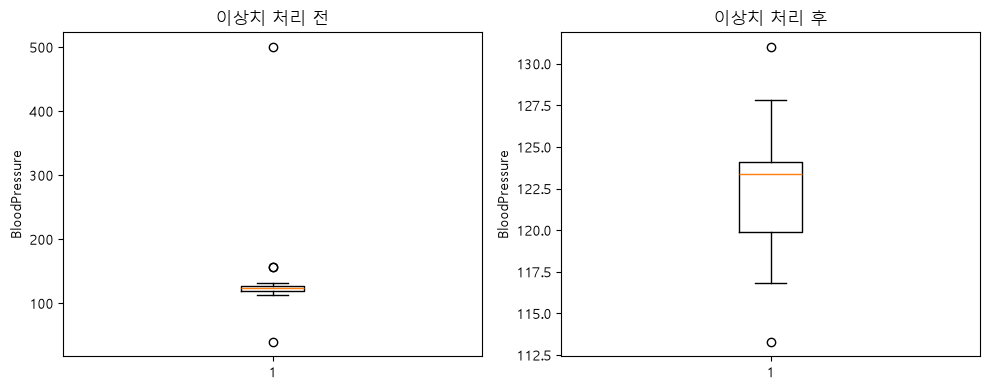

이상치를 중앙값(123.35)으로 대체 완료


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df["BloodPressure"])
axes[0].set_title("이상치 처리 전")
axes[0].set_ylabel("BloodPressure")

bp_median = df["BloodPressure"].median()
df.loc[outlier_mask, "BloodPressure"] = bp_median

axes[1].boxplot(df["BloodPressure"])
axes[1].set_title("이상치 처리 후")
axes[1].set_ylabel("BloodPressure")

plt.tight_layout()
plt.show()

print(f"이상치를 중앙값({bp_median:.2f})으로 대체 완료")


## 4. 데이터 타입 오류 수정

In [8]:
print("변환 전 ExamDate 타입:", df["ExamDate"].dtype)

df["ExamDate"] = pd.to_datetime(df["ExamDate"])

print("변환 후 ExamDate 타입:", df["ExamDate"].dtype)


변환 전 ExamDate 타입: str
변환 후 ExamDate 타입: datetime64[us]


## 5. 최종 결과 확인

In [9]:
print("=== 전처리 완료 데이터 정보 ===")
df.info()
print()
print("결측치 총합:", df.isnull().sum().sum())
print("중복 PatientID 수:", df["PatientID"].duplicated().sum())
df.head(10)


=== 전처리 완료 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   PatientID      20 non-null     int64         
 1   Age            20 non-null     float64       
 2   BMI            20 non-null     float64       
 3   BloodPressure  20 non-null     float64       
 4   Cholesterol    20 non-null     float64       
 5   ExamDate       20 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 1.1 KB

결측치 총합: 0
중복 PatientID 수: 0


,PatientID,Age,BMI,BloodPressure,Cholesterol,ExamDate
0,1001,52.000000,24.40,126.50,185.0,2026-01-05
1,1002,42.000000,23.00,125.30,201.0,2026-01-06
2,1003,48.444444,28.70,118.00,203.0,2026-01-07
3,1004,58.000000,24.55,123.40,212.0,2026-01-08
4,1005,34.000000,23.70,123.35,214.0,2026-02-01
5,1006,40.000000,23.90,123.30,215.0,2026-01-10
6,1007,48.444444,26.60,123.35,201.0,2026-01-11
7,1008,47.000000,24.55,123.30,203.0,2026-01-12
8,1009,50.000000,26.20,126.10,215.0,2026-01-13
9,1010,43.000000,26.30,122.40,203.0,2026-02-02


## 오늘의 회고

결측치를 무작정 하나의 방법(평균 또는 중앙값)으로만 처리하는 게 아니라, 컬럼의 분포 특성(이상치에 민감한지 여부)에 따라
평균/중앙값을 다르게 선택해야 하는 이유를 체감했다. 특히 BloodPressure처럼 이상치(500, 40)가 섞여 있는 컬럼은
평균이 왜곡되기 쉬운데, 이번 과제 순서상 결측치를 먼저 평균으로 채우고 이상치를 나중에 처리하다 보니
"이상치를 먼저 정리한 뒤 결측치를 채우는 순서가 더 안전하지 않을까?"라는 의문이 들었다. 실무에서는
전처리 단계의 순서 자체도 신중하게 설계해야 한다는 걸 배웠다.
